In [1]:

# 1: Date Feature Engineering

import pandas as pd
import numpy as np

# load data
sales_df = pd.read_csv('q3_retail_promotions.csv')

# convert to datetime
sales_df['transaction_date'] = pd.to_datetime(sales_df['transaction_date'])

# extract features
sales_df['year'] = sales_df['transaction_date'].dt.year
sales_df['month'] = sales_df['transaction_date'].dt.month
sales_df['day_of_week'] = sales_df['transaction_date'].dt.dayofweek

# create month end flag
sales_df['is_month_end'] = sales_df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

print("Sample Data with New Features:")
print(sales_df.head())

Sample Data with New Features:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1          

In [2]:

# 2: Temporal Train-Test Split

# sort by date
sorted_df = sales_df.sort_values(by='transaction_date')

# split index
split_index = int(0.8 * len(sorted_df))

train_df = sorted_df.iloc[:split_index]
test_df = sorted_df.iloc[split_index:]

print("Training size:", train_df.shape)
print("Testing size:", test_df.shape)

Training size: (960, 13)
Testing size: (240, 13)


### Temporal Train-Test Split

The dataset was sorted based on transaction_date and then split into training and testing sets.

- Training set size: 960 records
- Testing set size: 240 records

The first 80% of the data is used for training, and the most recent 20% is used for testing.

A random split is not suitable here because this is time-based data. In real-world situations, we always use past data to predict future outcomes.

If we randomly split the data, the model might learn from future data, which would give unrealistic and misleading results.

In [6]:

# PART 3: Preprocessing Pipeline


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# define features
target_column = 'items_sold'

X_train = train_df.drop(columns=[target_column, 'transaction_date'])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column, 'transaction_date'])
y_test = test_df[target_column]

# categorical and numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])


Linear Regression Performance:
RMSE: 27.121451164890626
MAE: 21.052926674588395

Random Forest Performance:
RMSE: 30.841610008504205
MAE: 24.240625


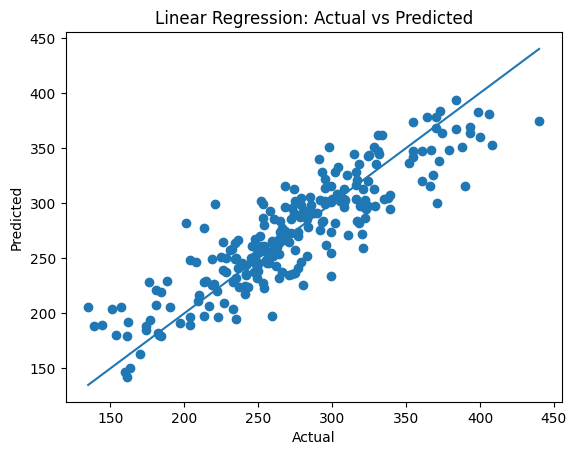

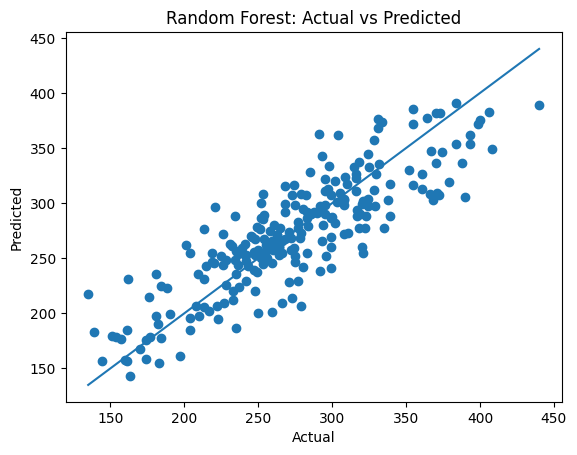


Top 5 Important Features:
                     feature  importance
13          num__is_festival    0.173473
10     cat__store_size_small    0.167683
7   cat__location_type_urban    0.108378
17          num__day_of_week    0.086316
12           num__is_weekend    0.061208


In [5]:
# PART 4: Model Training & Evaluation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

# evaluation
def evaluate_model(true, pred, name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    print(f"\n{name} Performance:")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest")

# parity plots
plt.scatter(y_test, lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

plt.scatter(y_test, rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# feature importance
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Features:")
print(importance_df.head())

## Model Evaluation

Both Linear Regression and Random Forest models were trained and evaluated using RMSE and MAE.

- Linear Regression Performance:
  - RMSE: 27.12
  - MAE: 21.05

- Random Forest Performance:
  - RMSE:30.84
  - MAE: 24.24

From the results, Linear Regression performs better than Random Forest because it has lower RMSE and MAE values. This means its predictions are closer to the actual values on average.

This suggests that the relationship between the features and items_sold is relatively simple and can be captured well by a linear model.

## Feature Importance

From the Random Forest model, the top important features are:

- is_festival (highest impact)
- store_size_small
- location_type_urban
- day_of_week
- is_weekend

This shows that sales are strongly influenced by whether it is a festival, the size of the store and the type of location.

### Conclusion

- Linear Regression is the better model for this dataset based on performance metrics.
- External factors like festivals, store size and timing (weekends and days) play a key role in predicting sales.